          施設名                            施設名(英語)    カテゴリ          電話番号  \
0       品川区役所              Shinagawa City Office     区役所  03-3777-1111   
1  品川第一地域センター  Shinagawa Dai-ichi Community Ctr.  地域センター  03-3450-2000   
2  品川第二地域センター    Shinagawa Dai-ni Community Ctr.  地域センター  03-3472-2000   
3  大崎第一地域センター      Osaki Dai-ichi Community Ctr.  地域センター  03-3491-2000   
4  大崎第二地域センター        Osaki Dai-ni Community Ctr.  地域センター  03-3492-2000   

       郵便番号                住所         緯度         経度  \
0  140-0005    東京都品川区広町2-1-36  35.608837  139.73024   
1  140-0001  東京都品川区北品川3-11-16  35.616681  139.74008   
2  140-0004   東京都品川区南品川5-3-20  35.611373  139.74129   
3  141-0031   東京都品川区西五反田3-6-3  35.627776  139.71686   
4  141-0032     東京都品川区大崎2-9-4  35.616945  139.72757   

                     geometry  
0  POINT (139.73024 35.60884)  
1  POINT (139.74008 35.61668)  
2  POINT (139.74129 35.61137)  
3  POINT (139.71686 35.62778)  
4  POINT (139.72757 35.61694)  
データの件数: 756 件


<Axes: >

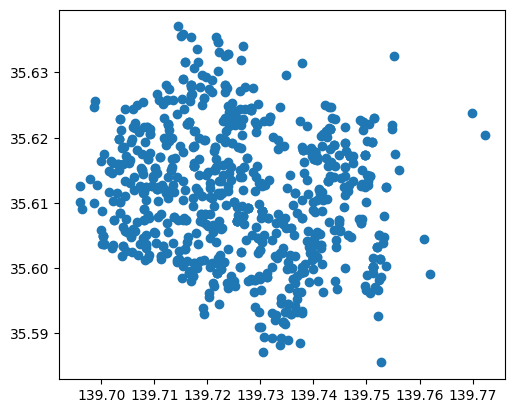

In [1]:
import pandas as pd
df = pd.read_csv("../data/kokyoshisetsu_edit.csv", encoding="cp932")
#df

import geopandas as gpd

df = df.loc[:, "施設名":"経度"]
geometry = gpd.points_from_xy(df['経度'], df['緯度'])
gdf = gpd.GeoDataFrame(df, geometry=geometry)
#gdf
gdf.crs=6668

# 最初の5行を表示
print(gdf.head())

# 行数と列数を確認
print(f"データの件数: {len(gdf)} 件")

gdf.plot()

## マーカーの設置

In [2]:
import folium
from IPython.display import display, IFrame 

# 品川駅　緯度経度
lat = 35.6291112
lon = 139.7389313

map = folium.Map(location=[lat, lon], zoom_start=13)

#choroplethで可視化
folium.Choropleth(
    gdf
).add_to(map)

map

#map.save("my_map.html")

#import webbrowser
#import os
#webbrowser.open('file://' + os.path.realpath("my_map.html"))


### ヒートマップの作製

In [3]:
import folium
from folium.plugins import HeatMap

#品川駅　緯度経度
lat = 35.6291112
lon = 139.7389313

map = folium.Map(location=[lat, lon], zoom_start=13)

pointlist = []
for index, row in df.iterrows():
    pointlist.append((row.緯度, row.経度))

HeatMap(pointlist, radius=20, blur=5).add_to(map)
map

map.save("heat_map.html")

#import webbrowser
#import os
#webbrowser.open('file://' + os.path.realpath("my_map.html"))

### ルート生成

In [4]:
import folium



# 経路の座標（緯度、経度）のリスト
route_coords = [
    (35.681236, 139.767125),  #東京駅
    (35.689487, 139.691711),  # 新宿駅
    (35.699739, 139.774219)   # 上野駅
]

# 地図の初期位置を経路の最初の地点に設定
map = folium.Map(location=route_coords[0], zoom_start=12)

pointlist = []
for index, row in df.iterrows():
    pointlist.append((row.緯度, row.経度))


#経路を描画（青色、太さ5)
folium.PolyLine(
    route_coords,
    #pointlist,
    color="blue",
    weight=5,
    opacity=0.8
).add_to(map)

#各地点にマーカーを追加
for idx, (lat, lon) in enumerate(route_coords, start=1):
    folium.Marker(
        location=(lat, lon),
        popup=f"Point {idx}"
    ).add_to(map)

map
map.save("direct_route_map.html")

In [ ]:
import folium
import openrouteservice
from openrouteservice import convert
import sys

def plot_route(api_key, start_coords, end_coords, output_html="route_map.html"):
    """
    Folium + OpenRouteServiceで経路を描画する関数
    :param api_key: OpenRouteService APIキー（文字列）
    :param start_coords: 出発地 (経度, 緯度) のタプル
    :param end_coords: 到着地 (経度, 緯度) のタプル
    :param output_html: 出力するHTMLファイル名
    """
    try:
        # APIクライアント作成
        client = openrouteservice.Client(key=api_key)

        # 経路取得（徒歩モード：'foot-walking', 車: 'driving-car'）
        route = client.directions(
            coordinates=[start_coords, end_coords],
            profile='driving-car',
            format='geojson'
        )
        # 中心座標を計算(出発地と到着地の中間)
        center_lat = (start_coords[1] + end_coords[1]) / 2
        center_lon = (start_coords[0] + end_coords[0]) / 2

        # Foliumマップ作製
        m = folium.Map(location=[center_lat, center_lon], zoom_start=13)

        # 経路を地図に追加
        folium.GeoJson(route, name="route").add_to(m)

        # 出発マーカー
        folium.Marker(
            location=[start_coords[1], start_coords[0]],
            popup="Start",
            icon=folium.Icon(color="green")
        ).add_to(m)

        # 到着マーカー
        folium.Marker(
            location=[end_coords[1], end_coords[0]],
            popup="End",
            icon=folium.Icon(color="red")
        ).add_to(m)

        # HTMLとして保存
        m.save(output_html)
        print(f"✅ 経路マップを '{output_html}' に保存しました。ブラウザで開いて確認してください。")
        
    except openrouteservice.exceptions.ApiError as e:
        print(f"APIエラー: {e}", file=sys.stderr)
    except Exception as e:
        print(f"エラーが発生しました: {e}", file=sys.stderr)

if __name__ == "__main__":
    #　ここに取得したAPIキーを入力
    API_KEY = "eyJvcmciOiI1YjNjZTM1OTc4NTExMTAwMDFjZjYyNDgiLCJpZCI6IjUzZTg5ZWNlMzFmYzQ4YTg4MjVhMWFkNDNlYjI4Y2UwIiwiaCI6Im11cm11cjY0In0="
    
    # 出発地と到着地（例: 東京駅 → 渋谷駅）
    start = (139.767125, 35.681236)  # 東京駅 (lon, lat)
    end = (139.701306, 35.658034)    # 渋谷駅 (lon, lat)

    plot_route(API_KEY, start, end)

## 羽田空港線の地図を作成する
https://chantastu.hatenablog.com/entry/2023/04/26/100437

In [ ]:
import folium
from folium import plugins

# 大鳥居付近を基準として地図を作成する
map = folium.Map(location=[35.54906167, 139.74149611], zoom_start=14)

# ミニマップを作成、地図にミニマップを表示
minimap = plugins.MiniMap()
map.add_child(minimap)
# line1のデータ
line_data1 = [
        [35.55471148, 139.78200228],
		[35.55386778, 139.78012639],
		[35.55246500, 139.77720194],
		[35.55012472, 139.77232333],
		[35.54978072, 139.77168391],
		[35.54678741, 139.76526418],
		[35.54676727, 139.76522090],
		[35.54614524, 139.76388684],
		[35.54588405, 139.76332665],
		[35.54550444, 139.76251250],
		[35.54548592, 139.76235234],
		[35.54575111, 139.76079083],
		[35.54580556, 139.76023472],
		[35.54581750, 139.76002361],
		[35.54583389, 139.75977778],
		[35.54584944, 139.75945944],
		[35.54584361, 139.75917028],
		[35.54579972, 139.75916333],
		[35.54590361, 139.75832139],
		[35.54595976, 139.75807155],
		[35.54600750, 139.75756639],
		[35.54607389, 139.75704806],
		[35.54611611, 139.75666306],
		[35.54615556, 139.75639444],
		[35.54625028, 139.75568972],
		[35.54633972, 139.75507167],
		[35.54638833, 139.75475083],
		[35.54642583, 139.75448417],
		[35.54649500, 139.75377944],
		[35.54661428, 139.75333103],
		[35.54662917, 139.75302972],
		[35.54677167, 139.75282500],
		[35.54680083, 139.75277111],
		[35.54681278, 139.75267028],
		[35.54687222, 139.75217306],
		[35.54694056, 139.75177833],
		[35.54695167, 139.75171611],
		[35.54698333, 139.75153611],
		[35.54698333, 139.75143944],
		[35.54701722, 139.75118444],
		[35.54707361, 139.75097778],
		[35.54712972, 139.75081944],
		[35.54712972, 139.75079861],
		[35.54733278, 139.75020611],
		[35.54741167, 139.74997861],
		[35.54758028, 139.74955139],
		[35.54759722, 139.74949611],
		[35.54765361, 139.74933778],
		[35.54768750, 139.74920667],
		[35.54769861, 139.74919306],
		[35.54778333, 139.74888278],
		[35.54784528, 139.74864861],
		[35.54791861, 139.74840056],
		[35.54792972, 139.74830389],
		[35.54793865, 139.74821489],
		[35.54810417, 139.74762167],
		[35.54814917, 139.74738056],
		[35.54818306, 139.74722889],
		[35.54825833, 139.74677444],
		[35.54835778, 139.74640222],
		[35.54852694, 139.74578222],
		[35.54867889, 139.74514833],
		[35.54867974, 139.74507509],
		[35.54887549, 139.74421563],
		[35.54892111, 139.74400444],
		[35.54895472, 139.74343250],
		[35.54900000, 139.74275028],
		[35.54902917, 139.74213778],
		[35.54903444, 139.74207972],
		[35.54906167, 139.74149611],
		[35.54913309, 139.74092757],
		[35.54913972, 139.74007139],
		[35.54914167, 139.74001667],
		[35.54920417, 139.73854306],
		[35.54928160, 139.73668584],
		[35.54932056, 139.73615583],
		[35.54940500, 139.73481917],
		[35.54947250, 139.73359250],
		[35.54948641, 139.73321141],
		[35.54953444, 139.73230417],
		[35.54963583, 139.73099500],
		[35.54969222, 139.73032667],
		[35.54977083, 139.72970639],
		[35.54996812, 139.72858254],
		[35.55000750, 139.72813528],
		[35.55006944, 139.72735000],
		[35.55013722, 139.72622667],
		[35.55024093, 139.72497187],
		[35.55023833, 139.72490361],
		[35.55025528, 139.72462111],
		[35.55032278, 139.72378056],
		[35.55033972, 139.72354611],
		[35.55041306, 139.72349806],
		[35.55055389, 139.72346361],
		[35.55063278, 139.72342222],
		[35.55095389, 139.72318111],
		[35.55104528, 139.72312833],
		[35.55110250, 139.72309500],
		[35.55116806, 139.72306389],
		[35.55142139, 139.72294667],
		[35.55184126, 139.72274302],
		[35.55192500, 139.72267139],
		[35.55205667, 139.72257944],
		[35.55205250, 139.72245056],
		[35.55202444, 139.72189250],
		[35.55200861, 139.72117111],
		[35.55201306, 139.72110028],
		[35.55203556, 139.72072139],
		[35.55210333, 139.72009417],
		[35.55213139, 139.71992194],
		[35.55214278, 139.71982556],
		[35.55219889, 139.71953611],
		[35.55233743, 139.71908766],
		[35.55237361, 139.71885389],
		[35.55243556, 139.71866778],
		[35.55245500, 139.71860389],
		[35.55248083, 139.71852306],
		[35.55259361, 139.71814444],
		[35.55317361, 139.71858500],
		[35.55412028, 139.71930167],
		[35.55430639, 139.71944639],
		[35.55450333, 139.71958389],
		[35.55516833, 139.72009389],
		[35.55535417, 139.72021806],
		[35.55564591, 139.72052157],
		[35.55650917, 139.72110667],
		[35.55735417, 139.72174750],
		[35.55751194, 139.72186444],
		[35.55795694, 139.72220194],
		[35.55800917, 139.72197833],
		[35.55806861, 139.72169639],
		[35.55815306, 139.72128694],
		[35.55816778, 139.72121639],
		[35.55818000, 139.72115917],
		[35.55835502, 139.72068835],
		[35.55848750, 139.71972833],
		[35.55858556, 139.71927250],
		[35.55867250, 139.71886694],
		[35.55875639, 139.71847722],
		[35.55883440, 139.71831812],
		[35.55921334, 139.71850859],
		[35.55992360, 139.71883248],
		[35.56003982, 139.71888300],
		[35.56049890, 139.71908254],
		[35.56059595, 139.71914393],
		[35.56063893, 139.71917112],
		[35.56071152, 139.71923812],
		[35.56075727, 139.71928035],
		[35.56078363, 139.71930946],
		[35.56084169, 139.71937362],
		[35.56099499, 139.71965162],
		[35.56106047, 139.71975820],
		[35.56107581, 139.71972340],
		[35.56122891, 139.71937278],
		[35.56136751, 139.71904473],
		[35.56143667, 139.71880473],
		[35.56148973, 139.71856390],
		[35.56149383, 139.71853964],
		[35.56149555, 139.71852945],
		[35.56152832, 139.71830733],
		[35.56164195, 139.71753723],
		[35.56170028, 139.71706194],
		[35.56171917, 139.71690751],
		[35.56224355, 139.71681482],
		[35.56262881, 139.71706146],
		[35.56262896, 139.71706156],
		[35.56264278, 139.71735140],
		[35.56265058, 139.71753028],
		[35.56265060, 139.71753071],
		[35.56265061, 139.71753074],
		[35.56265064, 139.71753109],
		[35.56269085, 139.71797673],
		[35.56269557, 139.71841195],
		[35.56270669, 139.71870836],
		[35.56274352, 139.71929404],
		[35.56274610, 139.71933528],
		[35.56274611, 139.71933542],
		[35.56274611, 139.71933545],
		[35.56274611, 139.71933553],
		[35.56274609, 139.71950974],
		[35.56274603, 139.71965931],
		[35.56270911, 139.71968836],
		[35.56268358, 139.71970843],
		[35.56265854, 139.71972814],
		[35.56258836, 139.71978337],
		[35.56224502, 139.72016920],
		[35.56214920, 139.72027253],
		[35.56185842, 139.72065507],
		[35.56161197, 139.72089609],
		[35.56162325, 139.72091000],
		[35.56163083, 139.72092050],
		[35.56163078, 139.72092054],
		[35.56161719, 139.72093248],
		[35.56138833, 139.72113364],
		[35.56094889, 139.72154696],
		[35.56089249, 139.72161585],
		[35.56028419, 139.72218807],
		[35.56011539, 139.72232200],
		[35.56007556, 139.72235360],
		[35.56006712, 139.72235705],
		[35.56000812, 139.72238122],
		[35.55996941, 139.72238933],
		[35.55994436, 139.72239459],
		[35.55994371, 139.72239472],
		[35.55988499, 139.72239500],
		[35.55988492, 139.72239500],
		[35.55977098, 139.72258337],
]
# Line2のデータ
line_data2 = [
        [35.53634938, 139.70824425],
		[35.53823709, 139.70856646],
		[35.53911436, 139.70871620],
		[35.53948063, 139.70878438],
		[35.54000622, 139.70888221],
		[35.54007108, 139.70889735],
		[35.54034641, 139.70895826],
		[35.54066162, 139.70906202],
		[35.54053833, 139.70939056],
		[35.54047972, 139.70954611],
		[35.54043806, 139.70964861],
		[35.54040559, 139.70992546],
		[35.54036694, 139.71017306],
		[35.54038389, 139.71026944],
		[35.54046833, 139.71057972],
		[35.54060361, 139.71091722],
		[35.54075028, 139.71124111],
		[35.54100389, 139.71178556],
		[35.54111056, 139.71206806],
		[35.54114389, 139.71217778],
		[35.54116611, 139.71225111],
		[35.54124583, 139.71255000],
		[35.54129392, 139.71269621],
		[35.54136972, 139.71299806],
		[35.54149389, 139.71334250],
		[35.54162333, 139.71360444],
		[35.54173611, 139.71373528],
		[35.54187139, 139.71385944],
		[35.54220389, 139.71407306],
		[35.54227139, 139.71410750],
		[35.54299806, 139.71455500],
		[35.54313333, 139.71464472],
		[35.54351667, 139.71492028],
		[35.54353917, 139.71494778],
		[35.54388861, 139.71520972],
		[35.54417028, 139.71543028],
		[35.54431667, 139.71556111],
		[35.54440139, 139.71568528],
		[35.54446333, 139.71581611],
		[35.54449667, 139.71591250],
		[35.54454907, 139.71622788],
		[35.54459250, 139.71643611],
		[35.54464889, 139.71667028],
		[35.54472611, 139.71690306],
		[35.54478972, 139.71709750],
		[35.54484056, 139.71722167],
		[35.54493083, 139.71747639],
		[35.54500389, 139.71770389],
		[35.54505722, 139.71785806],
		[35.54510194, 139.71798361],
		[35.54512806, 139.71805528],
		[35.54520111, 139.71827583],
		[35.54530833, 139.71855806],
		[35.54539833, 139.71879250],
		[35.54543778, 139.71892333],
		[35.54551176, 139.71917366],
		[35.54554500, 139.71932306],
		[35.54563500, 139.71957111],
		[35.54574000, 139.71986917],
		[35.54574778, 139.71988806],
		[35.54597333, 139.72040472],
		[35.54604083, 139.72059750],
		[35.54617028, 139.72107972],
		[35.54621869, 139.72153941],
		[35.54620389, 139.72167944],
		[35.54619278, 139.72207917],
		[35.54619861, 139.72247861],
		[35.54622694, 139.72260972],
		[35.54629417, 139.72279556],
		[35.54636167, 139.72289222],
		[35.54649139, 139.72319528],
		[35.54653639, 139.72329194],
		[35.54670000, 139.72369806],
		[35.54675667, 139.72383667],
		[35.54679000, 139.72393194],
		[35.54700972, 139.72454556],
		[35.54712250, 139.72482139],
		[35.54714481, 139.72488617],
		[35.54722389, 139.72498667],
		[35.54739861, 139.72529667],
		[35.54745139, 139.72553917],
		[35.54750333, 139.72581556],
		[35.54755139, 139.72608778],
		[35.54761278, 139.72652306],
		[35.54762972, 139.72675056],
		[35.54764083, 139.72684694],
		[35.54769014, 139.72698787],
		[35.54766361, 139.72709500],
		[35.54770306, 139.72750833],
		[35.54772556, 139.72774972],
		[35.54780444, 139.72813556],
		[35.54788333, 139.72843861],
		[35.54800722, 139.72894167],
		[35.54814250, 139.72958250],
		[35.54816500, 139.72972056],
		[35.54821368, 139.73011818],
		[35.54827778, 139.73033333],
		[35.54830944, 139.73052972],
		[35.54835111, 139.73078833],
		[35.54838472, 139.73104306],
		[35.54836806, 139.73159444],
		[35.54836250, 139.73181500],
		[35.54831750, 139.73222833],
		[35.54830611, 139.73229056],
		[35.54828389, 139.73239639],
		[35.54826111, 139.73249028],
		[35.54816500, 139.73278139],
		[35.54805722, 139.73305667],
		[35.54800750, 139.73318611],
		[35.54789472, 139.73341361],
		[35.54784942, 139.73349227],
		[35.54778583, 139.73361833],
		[35.54768056, 139.73382028],
		[35.54753417, 139.73406833],
		[35.54722444, 139.73446806],
		[35.54704417, 139.73468167],
		[35.54689194, 139.73490889],
		[35.54684139, 139.73501222],
		[35.54679611, 139.73515000],
		[35.54672306, 139.73550833],
		[35.54671167, 139.73552917],
		[35.54668361, 139.73571528],
		[35.54664972, 139.73586000],
		[35.54662167, 139.73604583],
		[35.54660922, 139.73622495],
		[35.54655389, 139.73641111],
		[35.54651472, 139.73660417],
		[35.54644722, 139.73699000],
		[35.54641889, 139.73714139],
		[35.54639083, 139.73729278],
		[35.54625556, 139.73803028],
		[35.54608083, 139.73896750],
		[35.54606694, 139.73906444],
		[35.54602556, 139.73934611],
		[35.54602306, 139.73946722],
		[35.54602750, 139.73993278],
		[35.54589966, 139.74091101],
		[35.54602563, 139.74125459],
		[35.54603399, 139.74127768],
		[35.54604331, 139.74127742],
		[35.54639363, 139.74126765],
		[35.54657806, 139.74126250],
		[35.54756500, 139.74105472],
		[35.54785583, 139.74099333],
		[35.54825028, 139.74096556],
		[35.54884698, 139.74093988],
		[35.54913309, 139.74092757],
		[35.54906167, 139.74149611],
		[35.54903444, 139.74207972],
		[35.54902917, 139.74213778],
		[35.54900000, 139.74275028],
		[35.54895472, 139.74343250],
		[35.54892111, 139.74400444],
		[35.54887548, 139.74421562],
		[35.54867974, 139.74507509],
		[35.54867889, 139.74514833],
		[35.54852694, 139.74578222],
		[35.54835778, 139.74640222],
		[35.54825833, 139.74677444],
		[35.54818306, 139.74722889],
		[35.54814917, 139.74738056],
		[35.54810417, 139.74762167],
		[35.54793865, 139.74821489],
		[35.54792972, 139.74830389],
		[35.54791861, 139.74840056],
		[35.54784528, 139.74864861],
		[35.54778333, 139.74888278],
		[35.54769861, 139.74919306],
		[35.54768750, 139.74920667],
		[35.54765361, 139.74933778],
		[35.54759722, 139.74949611],
		[35.54758028, 139.74955139],
		[35.54741167, 139.74997861],
		[35.54733278, 139.75020611],
		[35.54712972, 139.75079861],
		[35.54712972, 139.75081944],
		[35.54707361, 139.75097778],
		[35.54701722, 139.75118444],
		[35.54698333, 139.75143944],
		[35.54698333, 139.75153611],
		[35.54695167, 139.75171611],
		[35.54694056, 139.75177833],
		[35.54687222, 139.75217306],
		[35.54681278, 139.75267028],
		[35.54680083, 139.75277111],
		[35.54677167, 139.75282500],
		[35.54662917, 139.75302972],
		[35.54661428, 139.75333103],
		[35.54649500, 139.75377944],
		[35.54642583, 139.75448417],
		[35.54638833, 139.75475083],
		[35.54633972, 139.75507167],
		[35.54625028, 139.75568972],
		[35.54615556, 139.75639444],
		[35.54611611, 139.75666306],
		[35.54607389, 139.75704806],
		[35.54600750, 139.75756639],
		[35.54595976, 139.75807155],
		[35.54590361, 139.75832139],
		[35.54579972, 139.75916333],
		[35.54584361, 139.75917028],
		[35.54584944, 139.75945944],
		[35.54583389, 139.75977778],
		[35.54581750, 139.76002361],
		[35.54580556, 139.76023472],
		[35.54575111, 139.76079083],
		[35.54548592, 139.76235234],
		[35.54550444, 139.76251250],
		[35.54588405, 139.76332665],
		[35.54614524, 139.76388684],
		[35.54676727, 139.76522090],
		[35.54678741, 139.76526418],
		[35.54978072, 139.77168391],
		[35.55012472, 139.77232333],
		[35.55246500, 139.77720194],
		[35.55386778, 139.78012639],
		[35.55471148, 139.78200228],
    ]

# Line3のデータ
line_data3 = [
        [35.54680083, 139.75277111],
		[35.54681278, 139.75267028],
		[35.54687222, 139.75217306],
		[35.54694056, 139.75177833],
		[35.54695167, 139.75171611],
		[35.54698333, 139.75153611],
		[35.54698333, 139.75143944],
		[35.54701722, 139.75118444],
		[35.54707361, 139.75097778],
		[35.54712972, 139.75081944],
		[35.54712972, 139.75079861],
		[35.54733278, 139.75020611],
		[35.54741167, 139.74997861],
		[35.54758028, 139.74955139],
		[35.54759722, 139.74949611],
		[35.54765361, 139.74933778],
		[35.54768750, 139.74920667],
		[35.54769861, 139.74919306],
		[35.54778333, 139.74888278],
		[35.54784528, 139.74864861],
		[35.54791861, 139.74840056],
		[35.54792972, 139.74830389],
		[35.54793865, 139.74821489],
		[35.54810417, 139.74762167],
		[35.54814917, 139.74738056],
		[35.54818306, 139.74722889],
		[35.54825833, 139.74677444],
		[35.54835778, 139.74640222],
		[35.54852694, 139.74578222],
		[35.54867889, 139.74514833],
		[35.54867974, 139.74507509],
		[35.54887451, 139.74421511],
		[35.54892111, 139.74400444],
		[35.54895472, 139.74343250],
		[35.54900000, 139.74275028],
		[35.54902917, 139.74213778],
		[35.54903444, 139.74207972],
		[35.54906167, 139.74149611],
		[35.54913309, 139.74092757],
		[35.54994639, 139.74080694],
		[35.55080250, 139.74072417],
		[35.55087389, 139.74072472],
		[35.55108528, 139.74068472],
		[35.55134222, 139.74062194],
		[35.55241376, 139.74035207],
		[35.55237054, 139.74013227],
		[35.55237238, 139.74003609],
		[35.55237980, 139.73965064],
		[35.55238315, 139.73947509],
		[35.55239561, 139.73917557],
		[35.55241628, 139.73881640],
		[35.55242387, 139.73868441],
		[35.55242477, 139.73866950],
		[35.55242898, 139.73859946],
		[35.55244958, 139.73838176],
		[35.55245025, 139.73837458],
		[35.55245696, 139.73830476],
		[35.55251058, 139.73774608],
		[35.55255203, 139.73731117],
		[35.55255326, 139.73729823],
		[35.55259165, 139.73678054],
		[35.55260474, 139.73660579],
		[35.55266591, 139.73578887],
		[35.55266899, 139.73574250],
		[35.55267395, 139.73566841],
		[35.55272316, 139.73527687],
		[35.55274469, 139.73481167],
		[35.55275318, 139.73470978],
		[35.55275890, 139.73464123],
		[35.55277418, 139.73445562],
		[35.55280287, 139.73410866],
		[35.55282897, 139.73360203],
		[35.55283193, 139.73354448],
		[35.55283485, 139.73349736],
		[35.55283550, 139.73348696],
		[35.55284039, 139.73341141],
		[35.55289426, 139.73231748],
		[35.55289868, 139.73223252],
		[35.55290257, 139.73215949],
		[35.55296059, 139.73114035],
		[35.55297672, 139.73106469],
		[35.55298936, 139.73102176],
		[35.55300387, 139.73097177],
		[35.55316201, 139.73052645],
		[35.55319012, 139.73046304],
		[35.55341501, 139.72995678],
		[35.55347064, 139.72990425],
		[35.55352463, 139.72983526],
		[35.55357731, 139.72980279],
		[35.55409340, 139.72904963],
		[35.55435830, 139.72866303],
		[35.55438308, 139.72862781],
		[35.55448834, 139.72840581],
		[35.55520567, 139.72746259],
		[35.55529531, 139.72734948],
		[35.55533416, 139.72730029],
		[35.55596978, 139.72639789],
		[35.55606700, 139.72628949],
		[35.55610701, 139.72620637],
		[35.55650315, 139.72562302],
		[35.55655446, 139.72555095],
		[35.55662121, 139.72547121],
		[35.55711140, 139.72477262],
		[35.55716358, 139.72470518],
		[35.55717746, 139.72468724],
		[35.55718863, 139.72467295],
		[35.55722787, 139.72462278],
		[35.55735222, 139.72442726],
		[35.55744587, 139.72423102],
		[35.55748114, 139.72415696],
		[35.55762278, 139.72372372],
		[35.55791012, 139.72243093],
		[35.55795694, 139.72220194],
		[35.55815207, 139.72235085],
		[35.55855506, 139.72265833],
		[35.55893057, 139.72294513],
		[35.55920250, 139.72315280],
		[35.55939947, 139.72298060],
		[35.55953471, 139.72282891],
		[35.55977098, 139.72258337],
		[35.55988417, 139.72239500],
    ]

# PolyLineで線の描画
line1 = folium.PolyLine(line_data1, weight=5, color="#0000ff").add_to(map)
line2 = folium.PolyLine(line_data2, weight=5, color="#ff0000").add_to(map)
line3 = folium.PolyLine(line_data3, weight=5, color="#008000").add_to(map)

# PolyLineに沿ってテキストを表示
plugins.PolyLineTextPath(line1, "京浜急行バス・羽田京急バス　蒲41", offset=-5).add_to(map)
plugins.PolyLineTextPath(line2, "羽田京急バス　空51", offset=-5).add_to(map)
plugins.PolyLineTextPath(line3, "京浜急行バス・羽田京急バス　空31", offset=-5).add_to(map)

map
map.save("haneda_line_route.html")